# The Deutsch-Jozsa Algorithm

The Deutsch-Jozsa algorithm generalizes Deutsch's algorithm from a single-bit input to an $n$-bit input. It was one of the first examples of a quantum algorithm that is exponentially faster than any possible deterministic classical algorithm.

**The Problem:**
We are given a hidden Boolean function $f: \{0, 1\}^n \rightarrow \{0, 1\}$. 
We are promised that the function is either:
1.  **Constant:** Returns the exact same value (all 0s or all 1s) for all $2^n$ possible inputs.
2.  **Balanced:** Returns 0 for exactly half of the inputs, and 1 for the other half.

**The Goal:** Determine if the function is constant or balanced with the minimum number of queries.
* **Classically (Worst-Case):** We might have to check just over half of all possible inputs to be 100% certain. This requires $2^{n-1} + 1$ queries. As $n$ grows, this number grows exponentially.
* **Quantum:** The Deutsch-Jozsa algorithm finds the answer with exactly **one** query to the quantum oracle, regardless of how large $n$ is.

In [5]:
# Import necessary Qiskit libraries
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Initialize the simulator
simulator = AerSimulator()

## Step 1: Defining the n-qubit Oracles

Just like in the 1-qubit version, we need a quantum oracle $U_f$ that performs:
$$|x, y\rangle \xrightarrow{U_f} |x, y \oplus f(x)\rangle$$
Here, $x$ is an $n$-qubit register, and $y$ is a single ancilla qubit.

* **Constant Oracle:** We can either do nothing (for $f(x) = 0$) or apply an $X$ gate to the ancilla (for $f(x) = 1$).
* **Balanced Oracle:** A simple way to create a balanced function is to apply CNOT gates using each data qubit as a control and the ancilla as the target. To make it more generalized, we can wrap these controls in a random "hidden string" of $X$ gates.

Balanced Oracle for n=3:


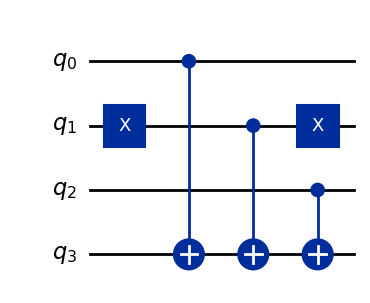

In [6]:
def dj_oracle(case, n):
    """
    Returns an n-qubit oracle circuit for the Deutsch-Jozsa algorithm.
    """
    # We need n data qubits + 1 ancilla qubit
    oracle_qc = QuantumCircuit(n + 1)
    
    if case == "constant":
        # Randomly decide if the constant output is 0 or 1
        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n) # Flip the ancilla to 1
            
    elif case == "balanced":
        # Generate a random binary string to determine which qubits get X gates
        b_str = np.random.randint(2, size=n)
        
        # Apply X gates to data qubits corresponding to 1s in the hidden string
        for qubit in range(n):
            if b_str[qubit] == 1:
                oracle_qc.x(qubit)
                
        # Apply CNOT gates from all data qubits to the ancilla
        for qubit in range(n):
            oracle_qc.cx(qubit, n)
            
        # Reverse the X gates to restore the state (uncomputation)
        for qubit in range(n):
            if b_str[qubit] == 1:
                oracle_qc.x(qubit)
                
    oracle_qc.name = f"Oracle ({case})"
    return oracle_qc

# Let's visualize a balanced oracle for n=3
n_test = 3
print(f"Balanced Oracle for n={n_test}:")
display(dj_oracle("balanced", n_test).draw('mpl'))

## Step 2: The Deutsch-Jozsa Circuit

The structure is identical to Deutsch's algorithm, just scaled up:
1.  Initialize the $n$-qubit data register to $|0\dots0\rangle$ and the ancilla to $|1\rangle$.
2.  Apply Hadamard gates to all $n+1$ qubits to create a massive superposition of all possible inputs.
3.  Apply the $n$-qubit Oracle. Phase kickback applies a negative phase to states corresponding to $f(x)=1$.
4.  Apply Hadamard gates to the $n$ data qubits. This creates constructive interference for the $|0\dots0\rangle$ state if the function was constant, and destructive interference if it was balanced.
5.  Measure the data register.
    * If we measure all zeros ($|00\dots0\rangle$), the function is **Constant**.
    * If we measure literally anything else, the function is **Balanced**.

Deutsch-Jozsa Circuit Architecture:


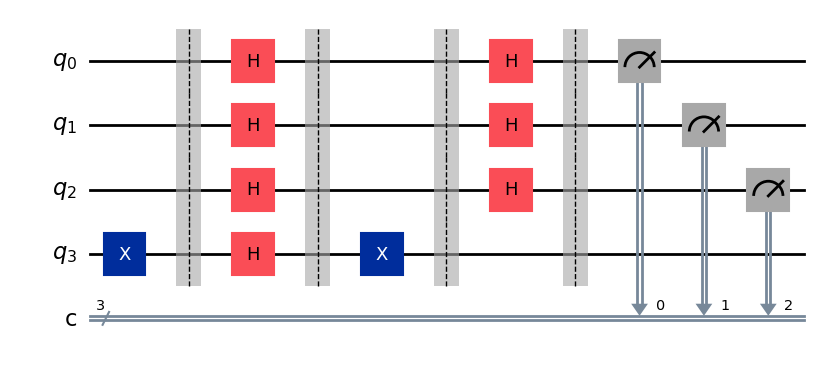

In [8]:
def dj_algorithm(oracle, n):
    """
    Constructs the Deutsch-Jozsa circuit for a given n-qubit oracle.
    """
    # n data qubits, 1 ancilla, and n classical bits for measurement
    qc = QuantumCircuit(n + 1, n)
    
    # 1. Initialization: Put the ancilla in state |1>
    qc.x(n)
    qc.barrier()
    
    # 2. Superposition: Apply H-gates to all qubits
    for qubit in range(n + 1):
        qc.h(qubit)
    qc.barrier()
    
    # 3. Apply Oracle
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 4. Interference: Apply H-gates to data qubits
    for qubit in range(n):
        qc.h(qubit)
    qc.barrier()
    
    # 5. Measurement: Measure data qubits
    for i in range(n):
        qc.measure(i, i)
        
    return qc

# Visualize the full circuit for n=3
n = 3
test_oracle = dj_oracle("constant", n)
dj_circuit = dj_algorithm(test_oracle, n)
print("Deutsch-Jozsa Circuit Architecture:")
display(dj_circuit.draw('mpl'))

## Step 3: Running the Algorithm

Let's test our algorithm by running both a constant and a balanced oracle for a specific number of qubits (let's use $n=4$). 

We will see that the constant oracle returns exactly `0000` 100% of the time, while the balanced oracle returns a different bitstring 100% of the time.

Constant Oracle | Measured: 0000 | Conclusion: Constant
Balanced Oracle | Measured: 1111 | Conclusion: Balanced


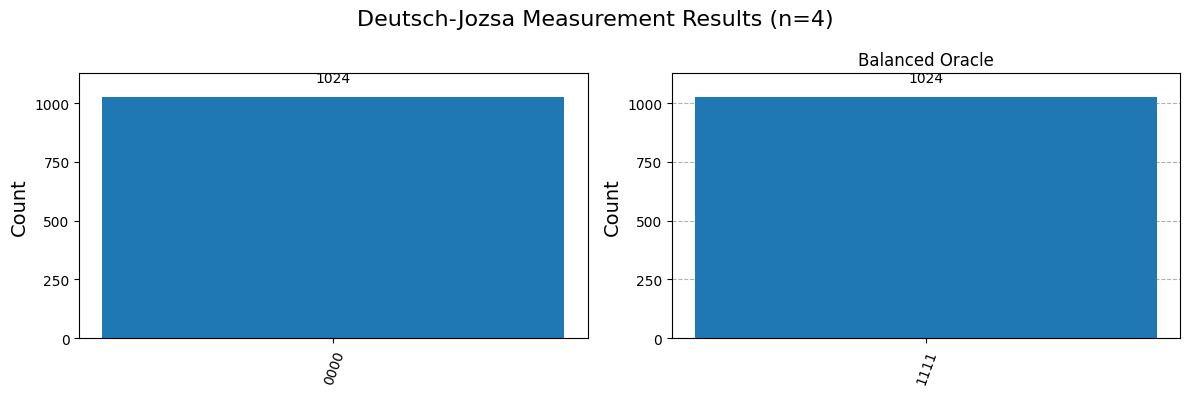

In [9]:
n = 4 # You can change this number to see it work for different sizes!

# Create one of each oracle
oracles = {
    "Constant Oracle": dj_oracle("constant", n),
    "Balanced Oracle": dj_oracle("balanced", n)
}

results_data = {}

for name, oracle in oracles.items():
    # Build circuit
    circuit = dj_algorithm(oracle, n)
    
    # Transpile and run
    transpiled_circuit = transpile(circuit, simulator)
    job = simulator.run(transpiled_circuit, shots=1024)
    counts = job.result().get_counts()
    results_data[name] = counts
    
    # Analyze outcome
    measured_state = list(counts.keys())[0]
    expected_constant_state = "0" * n
    
    conclusion = "Constant" if measured_state == expected_constant_state else "Balanced"
    print(f"{name} | Measured: {measured_state} | Conclusion: {conclusion}")

# Plot histograms
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Deutsch-Jozsa Measurement Results (n={n})', fontsize=16)

for i, (name, counts) in enumerate(results_data.items()):
    plot_histogram(counts, ax=ax[i], title=name)

plt.tight_layout()
plt.show()